# Matplotlib + Seaborn
**Data Visualization (Part 1)**

These are your two workhorses for static plots — model diagnostics, EDA, papers, reports.

**Mental model:**
- **Matplotlib** = the engine. Full control, more code. You use it directly when Seaborn can't do something.
- **Seaborn** = built on top of Matplotlib. Statistical plots with less code. Use it for EDA and distributions.
- They mix freely — you can style a Seaborn plot using Matplotlib commands.

**When to use which:**
| Task | Use |
|---|---|
| Training curves, ROC, custom layouts | Matplotlib |
| Distribution, correlation, pairplot, heatmap | Seaborn |
| Confusion matrix | Seaborn (`heatmap`) |
| Subplots with mixed chart types | Matplotlib (`fig, axes`) |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve

np.random.seed(42)

# Shared dataset — employee churn scenario
n = 300
df = pd.DataFrame({
    'age':               np.random.randint(22, 58, n),
    'experience':        np.random.randint(1, 20, n),
    'salary':            np.random.normal(70000, 15000, n),
    'satisfaction':      np.random.uniform(1, 5, n),
    'hours_per_week':    np.random.normal(42, 8, n),
    'department':        np.random.choice(['Engineering', 'Sales', 'Marketing', 'HR'], n),
    'performance':       np.random.choice(['Low', 'Mid', 'High'], n),
    'churn':             np.random.choice([0, 1], n, p=[0.75, 0.25])
})

print(df.shape)
df.head()

(300, 8)


,age,experience,salary,satisfaction,hours_per_week,department,performance,churn
0,50,1,74997.599423,4.898189,38.125527,Engineering,Mid,0
1,36,8,66131.467532,4.119035,39.163007,Engineering,Mid,0
2,29,14,17827.461795,1.456952,27.225821,Marketing,High,0
3,42,16,65976.054071,3.263106,37.466645,Marketing,Low,0
4,40,14,62231.316163,4.941469,51.307884,HR,Low,0


---
## PART 1: Matplotlib

### 1.1 The Core API — `fig, ax` Pattern

This is the one thing to internalize. Always use the object-oriented API, not `plt.plot()` directly.

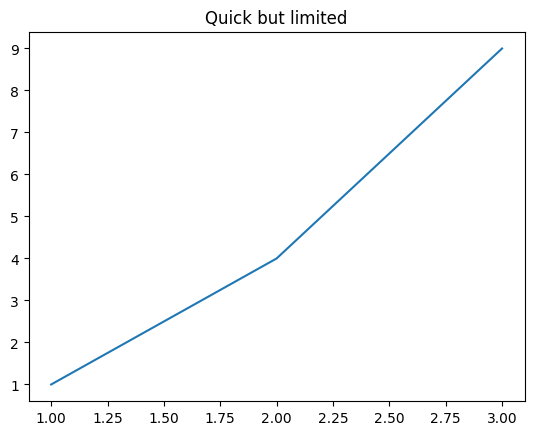

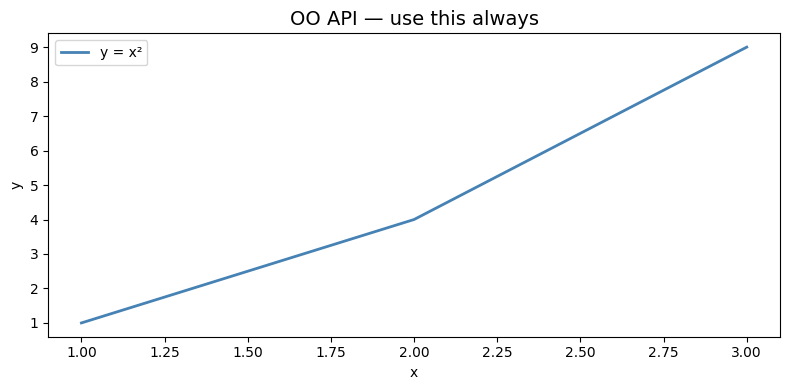

In [2]:
# TWO STYLES — always use the bottom one

# STYLE 1: pyplot API (quick, but breaks with subplots)
plt.plot([1, 2, 3], [1, 4, 9])
plt.title('Quick but limited')
plt.show()

# STYLE 2: Object-oriented API (use this — scales to any complexity)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3], [1, 4, 9], color='steelblue', linewidth=2, label='y = x²')
ax.set_title('OO API — use this always', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()

# fig = the whole figure (canvas)
# ax  = one plot inside the figure
# With subplots you get multiple ax objects — that's why OO API matters

### 1.2 Training Curves — Most Common ML Plot

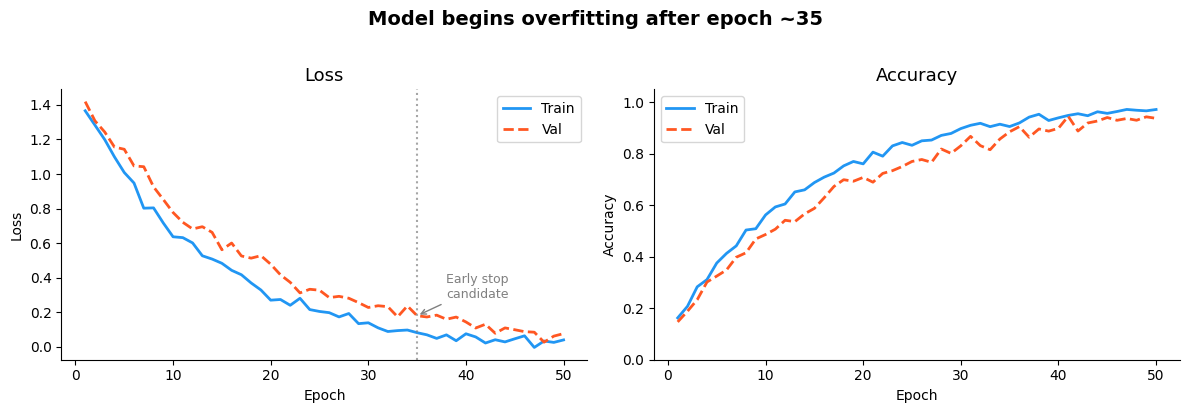

In [3]:
epochs = np.arange(1, 51)
train_loss = 1.5 * np.exp(-0.08 * epochs) + np.random.normal(0, 0.02, 50)
val_loss   = 1.5 * np.exp(-0.06 * epochs) + np.random.normal(0, 0.03, 50)
train_acc  = 1 - 0.9 * np.exp(-0.07 * epochs) + np.random.normal(0, 0.01, 50)
val_acc    = 1 - 0.9 * np.exp(-0.055 * epochs) + np.random.normal(0, 0.015, 50)


# plt.subplots(nrows, ncols, figsize)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss subplot
ax1.plot(epochs, train_loss, label='Train', color='#2196F3', linewidth=2)
ax1.plot(epochs, val_loss,   label='Val',   color='#FF5722', linewidth=2, linestyle='--')
ax1.axvline(x=35, color='gray', linestyle=':', alpha=0.7)   # early stopping point
ax1.annotate('Early stop\ncandidate', xy=(35, val_loss[34]),
             xytext=(38, val_loss[34] + 0.1),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color='gray')
ax1.set_title('Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)  # remove chart borders

# Accuracy subplot
ax2.plot(epochs, np.clip(train_acc, 0, 1), label='Train', color='#2196F3', linewidth=2)
ax2.plot(epochs, np.clip(val_acc, 0, 1),   label='Val',   color='#FF5722', linewidth=2, linestyle='--')
ax2.set_title('Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Model begins overfitting after epoch ~35', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.3 ROC Curve

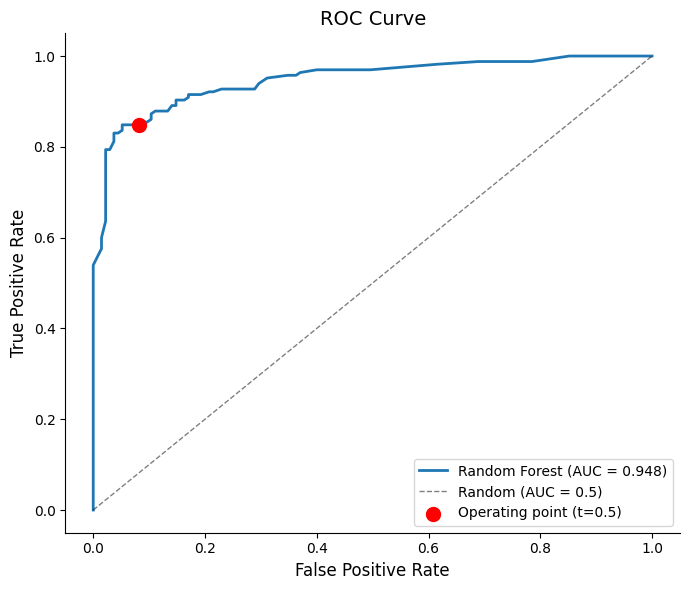

In [4]:
# Generate a real ROC curve from sklearn
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

# Highlight a specific operating point (e.g., threshold = 0.5)
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
op_fpr = fp / (fp + tn)
op_tpr = tp / (tp + fn)
ax.scatter([op_fpr], [op_tpr], s=100, zorder=5, color='red',
           label=f'Operating point (t=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14)
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 1.4 Feature Importance (Horizontal Bar)

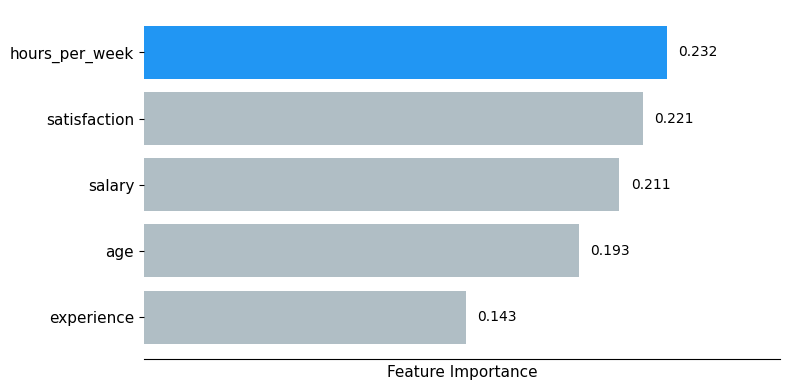

In [5]:
# Train a model on our churn dataset
features = ['age', 'experience', 'salary', 'satisfaction', 'hours_per_week']
X_churn = df[features]
y_churn = df['churn']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_churn, y_churn)

importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))

# Color the top feature differently
colors = ['#2196F3' if i == importances.idxmax() else '#B0BEC5' for i in importances.index]

bars = ax.barh(importances.index, importances.values, color=colors)

# Add value labels
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Feature Importance', fontsize=11)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index, fontsize=11)
ax.set_xlim(0, importances.max() + 0.05)
ax.tick_params(axis='x', bottom=False, labelbottom=False)  # values on bars, x ticks redundant
plt.tight_layout()
plt.show()

### 1.5 Learning Curve — Diagnosing Bias vs Variance

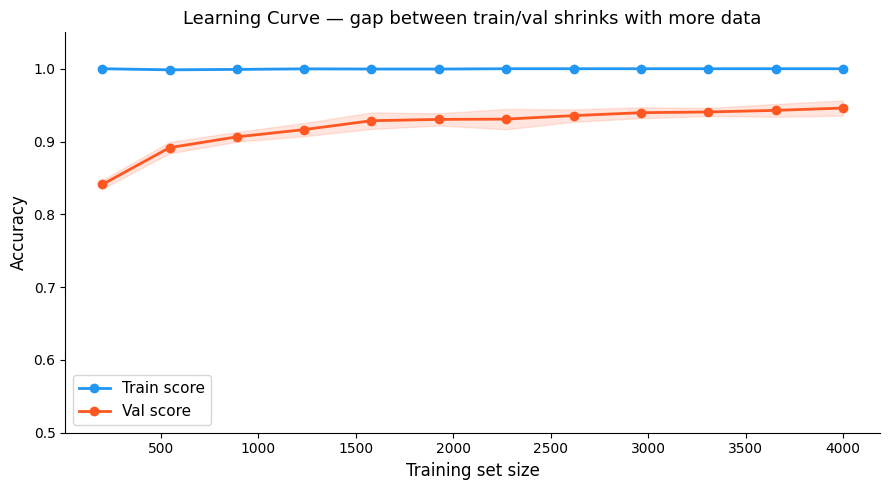

In [6]:
# Using 5000 samples so the gap actually closes visibly —
# with only 300 rows RF memorizes everything (train=1.0) and the curve is flat
X_lc, y_lc = make_classification(
    n_samples=5000, n_features=20, n_informative=10,
    n_redundant=5, random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_lc, y_lc,
    train_sizes=np.linspace(0.05, 1.0, 12),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Train score', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2196F3')

ax.plot(train_sizes, val_mean, 'o-', color='#FF5722', label='Val score', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#FF5722')

ax.set_xlabel('Training set size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve — gap between train/val shrinks with more data', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# What the gap tells you:
# Large gap (train >> val) → overfitting — add more data or regularize
# No gap but both low     → underfitting — try a more complex model
# Gap closes as n grows   → adding data helps (what we see here)


### 1.6 Subplots — Grid Layouts

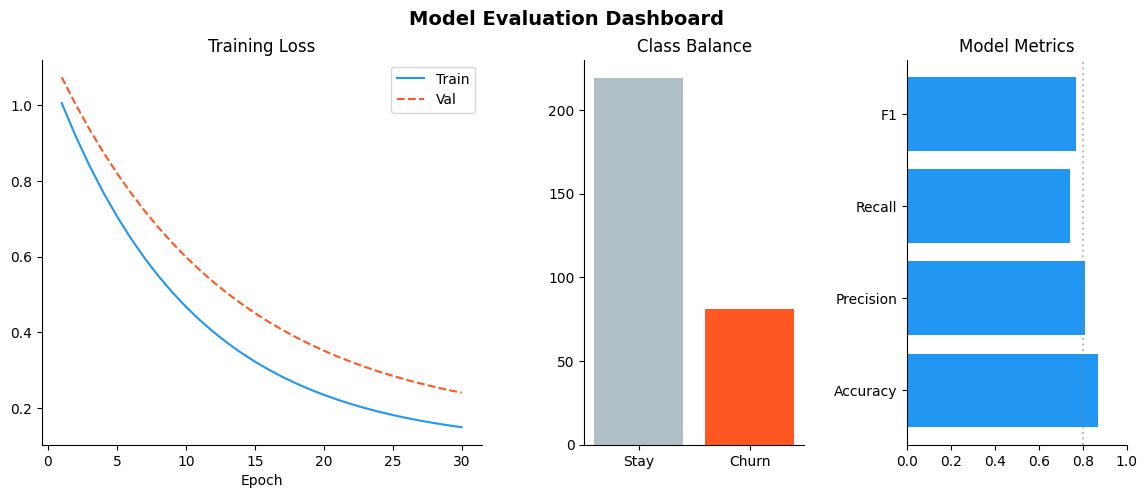

In [7]:
# gridspec gives you unequal subplot sizes — useful for dashboards
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1], wspace=0.35)

ax1 = fig.add_subplot(gs[0])   # wide left panel
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: training curve
ep = np.arange(1, 31)
ax1.plot(ep, np.exp(-0.1 * ep) + 0.1, label='Train', color='#2196F3')
ax1.plot(ep, np.exp(-0.08 * ep) + 0.15, label='Val', color='#FF5722', linestyle='--')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2: class balance
churn_counts = df['churn'].value_counts()
ax2.bar(['Stay', 'Churn'], churn_counts.values, color=['#B0BEC5', '#FF5722'])
ax2.set_title('Class Balance')
ax2.spines[['top', 'right']].set_visible(False)

# Panel 3: metric summary
metrics = {'Accuracy': 0.87, 'Precision': 0.81, 'Recall': 0.74, 'F1': 0.77}
ax3.barh(list(metrics.keys()), list(metrics.values()), color='#2196F3')
ax3.set_xlim(0, 1)
ax3.axvline(x=0.8, color='gray', linestyle=':', alpha=0.5)   # draws a vertical line (we also have axhline for horizontal line)
ax3.set_title('Model Metrics')
ax3.spines[['top', 'right']].set_visible(False)

fig.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.show()

### 1.7 Reusable Plot Style — Set Once, Apply Everywhere

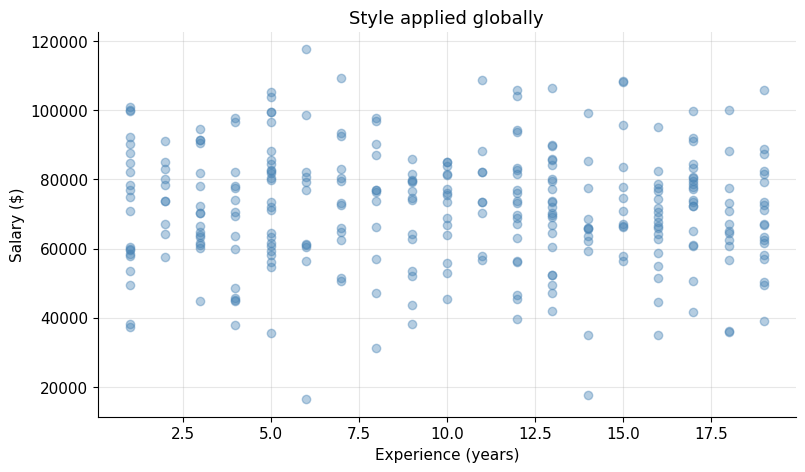

In [8]:
# Set a global style at the top of any notebook or script
# rcParams = global style defaults — set once, applies to every plot after this
#rcParams stands for runtime configuration parameters — it's a dictionary that controls the default appearance of all Matplotlib plots.

plt.rcParams.update({
    'figure.figsize':    (9, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

# Built-in styles (pick one you like)
# plt.style.use('seaborn-v0_8-whitegrid')  # clean, good for ML
# plt.style.use('ggplot')                  # R-style
# plt.style.use('fivethirtyeight')         # bold and punchy

# After setting rcParams, all subsequent plots inherit these defaults
fig, ax = plt.subplots()
ax.plot(df['experience'], df['salary'], 'o', alpha=0.4, color='steelblue')
ax.set_title('Style applied globally')
ax.set_xlabel('Experience (years)')
ax.set_ylabel('Salary ($)')
plt.show()

### 1.8 Saving Figures

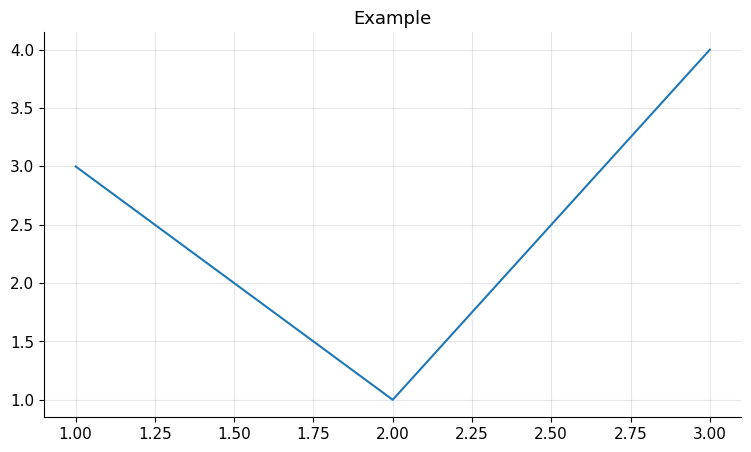

In [9]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [3, 1, 4])
ax.set_title('Example')

# dpi=150 for screen, dpi=300 for print/papers
# bbox_inches='tight' prevents labels getting clipped
# fig.savefig('output.png', dpi=150, bbox_inches='tight')
# fig.savefig('output.pdf', bbox_inches='tight')   # vector format — scales perfectly

plt.show()

---
## PART 2: Seaborn

### Why Seaborn?
Seaborn wraps Matplotlib with statistical awareness — it understands DataFrames natively and adds confidence intervals, regression lines, and statistical annotations automatically.

**The two things Seaborn does that make it worth using:**
1. Distribution + statistics in one call
2. Beautiful defaults with less code

## Matplotlib vs Seaborn

Matplotlib is low-level — you control everything but you have to compute everything yourself.
Seaborn is high-level — less code, and it handles the statistics for you.

---

### The Difference in Practice

```python
# Matplotlib — you do the math yourself
mean = df.groupby('department')['salary'].mean()
std  = df.groupby('department')['salary'].std()
ax.bar(mean.index, mean.values)
ax.errorbar(mean.index, mean.values, yerr=std)  # manually add error bars
```

```python
# Seaborn — just point it at the DataFrame
sns.barplot(data=df, x='department', y='salary')
# mean + confidence interval drawn automatically
```

Same result, but Seaborn computed the aggregation and uncertainty for you.

---

### What "Statistically Aware" Means

Seaborn understands that your data has **groups, distributions, and uncertainty** — and it visualizes those things without you computing them first.

- `barplot` → automatically shows mean + confidence interval
- `boxplot` → automatically shows median, quartiles, and outliers
- `histplot` → automatically bins and optionally fits a distribution

---

### What "Understands DataFrames Natively" Means

You pass `data=df` and refer to columns by name — you never need to extract arrays manually.

```python
# Matplotlib — extract arrays first
ax.scatter(df['age'].values, df['salary'].values)

# Seaborn — just use column names
sns.scatterplot(data=df, x='age', y='salary', hue='department')
```

---

### When to Use Which

| Situation | Use |
|-----------|-----|
| Full control over every detail | Matplotlib |
| Quick statistical plots from a DataFrame | Seaborn |
| Custom subplots, layouts, annotations | Matplotlib |
| Distribution plots, grouped comparisons | Seaborn |

> Seaborn is built on top of Matplotlib — you can always drop into Matplotlib to fine-tune a Seaborn plot after the fact.

In [10]:
# Set Seaborn theme once at the top
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
# style options: whitegrid, darkgrid, white, dark, ticks
# palette options: muted, deep, bright, colorblind (use colorblind-safe for reports)

### 2.1 Distribution Plots — Always Check Before Modeling

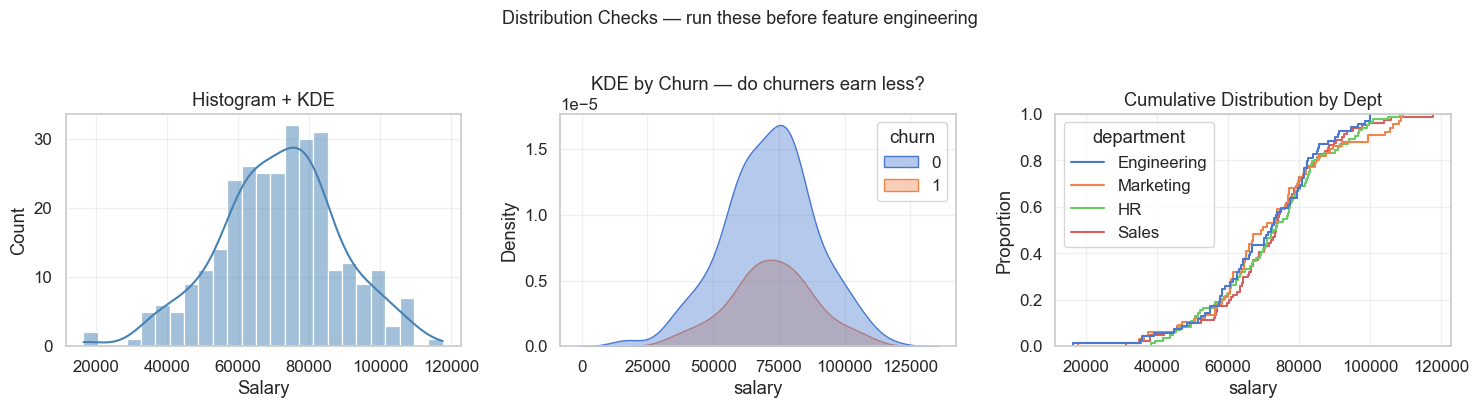

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# histplot — histogram + optional KDE (kde - kernel density estimation - smoothes out the bins for smooth curve)
sns.histplot(df['salary'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram + KDE')
axes[0].set_xlabel('Salary')

# kdeplot — smooth density estimate only
sns.kdeplot(data=df, x='salary', hue='churn', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('KDE by Churn — do churners earn less?')

# ecdfplot — cumulative distribution (good for percentile analysis)
sns.ecdfplot(data=df, x='salary', hue='department', ax=axes[2])
axes[2].set_title('Cumulative Distribution by Dept')

plt.suptitle('Distribution Checks — run these before feature engineering', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

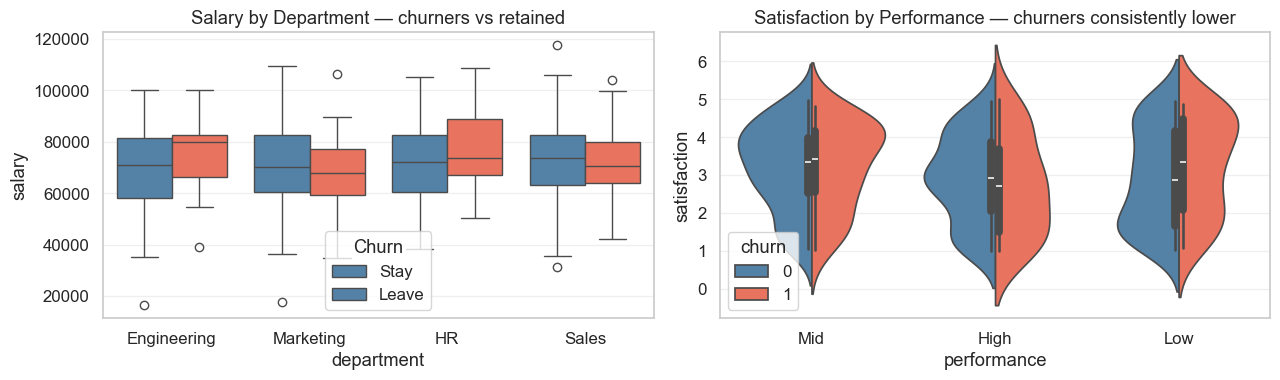

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# boxplot — median, IQR, outliers
sns.boxplot(data=df, x='department', y='salary', hue='churn',
            palette={0: 'steelblue', 1: 'tomato'}, ax=axes[0])
axes[0].set_title('Salary by Department — churners vs retained')
axes[0].legend(title='Churn', labels=['Stay', 'Leave'])

# violinplot — like boxplot but shows full distribution shape
sns.violinplot(data=df, x='performance', y='satisfaction',
               hue='churn', split=True,   # split=True overlays two halves
               palette={0: 'steelblue', 1: 'tomato'}, ax=axes[1])
axes[1].set_title('Satisfaction by Performance — churners consistently lower')

plt.tight_layout()
plt.show()

### 2.2 Correlation Heatmap — Essential for Feature Selection

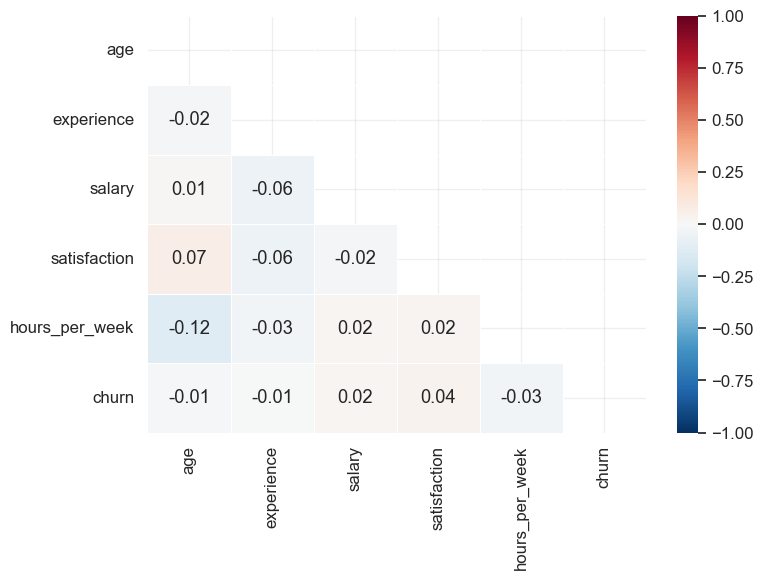

In [13]:
numeric_cols = ['age', 'experience', 'salary', 'satisfaction', 'hours_per_week', 'churn']
corr = df[numeric_cols].corr()

# mask the upper triangle (redundant info)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # show correlation values
    fmt='.2f',
    cmap='RdBu_r',       # red = positive, blue = negative
    vmin=-1, vmax=1,     # fix color scale to [-1, 1]
    linewidths=0.5,
    ax=ax
)
plt.tight_layout()
plt.show()

# What to look for:
# - High correlation with target (good predictor)
# - High correlation between features (multicollinearity — may need to drop one)

### 2.3 Confusion Matrix — The Standard ML Evaluation Plot

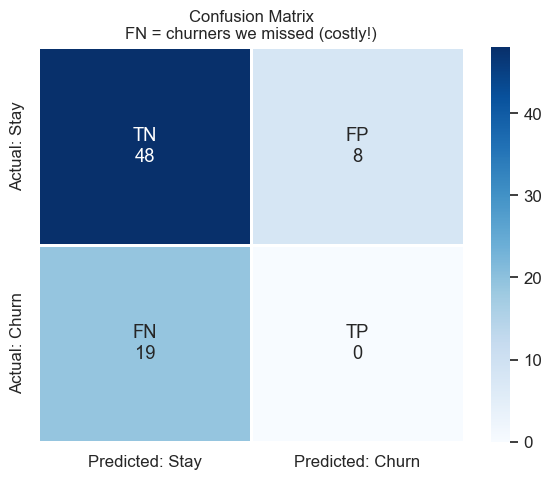

              precision    recall  f1-score   support

        Stay       0.72      0.86      0.78        56
       Churn       0.00      0.00      0.00        19

    accuracy                           0.64        75
   macro avg       0.36      0.43      0.39        75
weighted avg       0.53      0.64      0.58        75



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['churn'], test_size=0.25, random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm_labels = np.array([['TN', 'FP'], ['FN', 'TP']])

# Annotate with both count and label
annot = np.array([[f'{cm_labels[i][j]}\n{cm[i][j]}' for j in range(2)] for i in range(2)])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=annot, fmt='',
    cmap='Blues',
    xticklabels=['Predicted: Stay', 'Predicted: Churn'],
    yticklabels=['Actual: Stay', 'Actual: Churn'],
    linewidths=1, linecolor='white',
    ax=ax
)
ax.set_title('Confusion Matrix\nFN = churners we missed (costly!)', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

### 2.4 Pairplot — Fast Multivariate EDA

## Pair Plot

A pair plot shows **every feature plotted against every other feature** in a grid. One chart to get a full picture of your dataset.

```python
sns.pairplot(df, hue='target')
```

---

### How to Read It

```
         age        salary     experience
age    [hist]    [age vs sal]  [age vs exp]
salary [sal vs age] [hist]    [sal vs exp]
exp    [exp vs age] [exp vs sal]  [hist]
```

- **Diagonal** → distribution of each feature on its own (histogram or KDE)
- **Off-diagonal** → scatter plot of one feature against another
- **`hue='target'`** → colors points by class — lets you see if classes are separable

---

### What to Look For

**Linear pattern** → two features are correlated — potential multicollinearity
```
salary vs experience going diagonally up → positive correlation
```

**Separated color clusters** → the model should be able to distinguish classes using those features
```
two clean color blobs → good feature for classification
completely overlapping → feature may not help much
```

**Curved or non-linear pattern** → relationship exists but linear models may miss it

**No pattern / random scatter** → features are independent of each other

---

### Practical Tips

- Use `hue=` always — without it you lose the most useful information
- Pair plots get slow and cluttered beyond ~8 features — select important ones first
- Diagonal KDE curves are more informative than histograms for spotting overlap between classes
- A scatter plot that shows clean separation by color = strong feature for your model

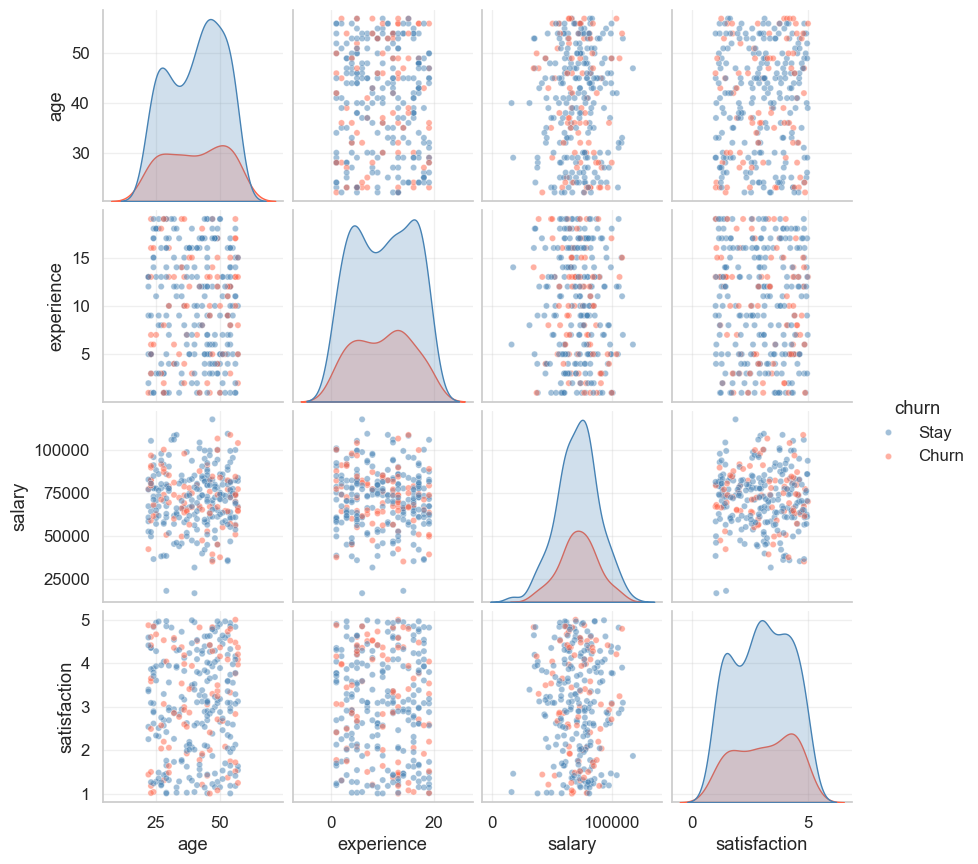

In [15]:
# Scatter matrix: every numeric feature against every other, colored by target
# Expensive on large datasets — sample first if n > 1000

pair_cols = ['age', 'experience', 'salary', 'satisfaction', 'churn']
pair_df = df[pair_cols].copy()
pair_df['churn'] = pair_df['churn'].map({0: 'Stay', 1: 'Churn'})

g = sns.pairplot(
    pair_df,
    hue='churn',
    palette={'Stay': 'steelblue', 'Churn': 'tomato'},
    diag_kind='kde',     # diagonal: KDE per class (shows separation)
    plot_kws=dict(alpha=0.5, s=20),
    height=2.2
)

plt.show()

# What to look for in a pairplot:
# - Clean separation between class colors → feature is discriminative
# - Diagonal KDEs with different peaks → classes have different distributions
# - Strong linear patterns in scatter → high correlation (potential collinearity)

### 2.5 Categorical Plots — Group Comparisons

## Categorical Plots

Used when one axis is a category (department, gender, product type) and the other is numeric.

```python
sns.boxplot(data=df, x='department', y='salary', hue='gender')
sns.violinplot(data=df, x='department', y='salary')
sns.barplot(data=df, x='department', y='salary')   # mean + CI automatically
sns.stripplot(data=df, x='department', y='salary')  # raw points
sns.swarmplot(data=df, x='department', y='salary')  # raw points, no overlap
```

### Which to Use When

| Plot | Use when |
|------|----------|
| `boxplot` | You want median, spread, and outliers |
| `violinplot` | You want the full distribution shape per group |
| `barplot` | You want to compare group means |
| `stripplot` | You want to see every raw data point |
| `swarmplot` | Same as strip but points don't overlap — better for small data |

> `boxplot` + `stripplot` together is a common combination — shows both summary statistics and raw points at once.

```python
sns.boxplot(data=df, x='department', y='salary')
sns.stripplot(data=df, x='department', y='salary', color='black', alpha=0.4)
```

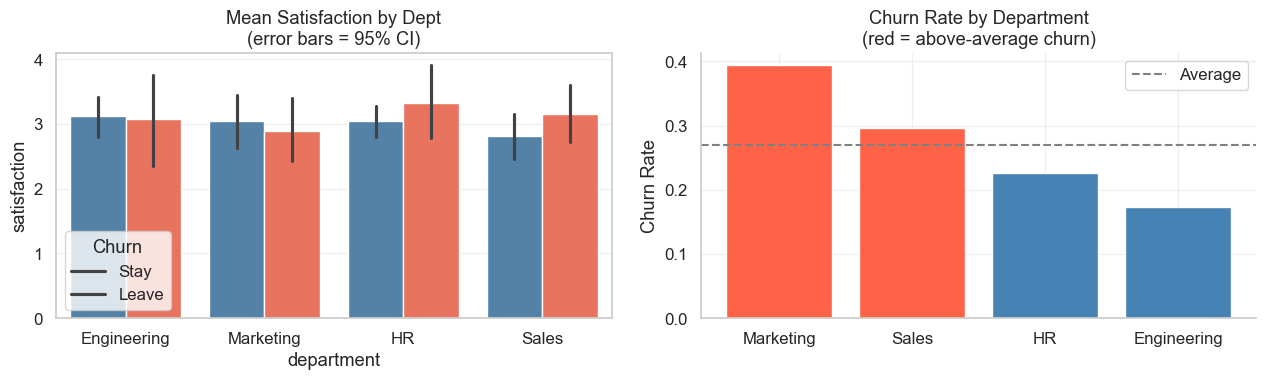

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# barplot — shows mean + 95% confidence interval automatically
sns.barplot(
    data=df, x='department', y='satisfaction',
    hue='churn',
    palette={0: 'steelblue', 1: 'tomato'},
    ax=axes[0]
)
axes[0].set_title('Mean Satisfaction by Dept\n(error bars = 95% CI)')
axes[0].legend(title='Churn', labels=['Stay', 'Leave'])

# countplot — frequency of categories
churn_rate = df.groupby('department')['churn'].mean().reset_index()
churn_rate = churn_rate.sort_values('churn', ascending=False)
bar_colors = ['tomato' if r > 0.28 else 'steelblue' for r in churn_rate['churn']]
axes[1].bar(churn_rate['department'], churn_rate['churn'], color=bar_colors)
axes[1].set_title('Churn Rate by Department\n(red = above-average churn)')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(df['churn'].mean(), color='gray', linestyle='--', label='Average')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2.6 Residual Plot — For Regression Models

## Residual Plot

A residual is the difference between the actual value and the predicted value.

```
residual = actual − predicted
```

`sns.residplot` plots residuals on the y-axis against predicted values on the x-axis. It tells you whether your model's errors are random or systematic.

```python
sns.residplot(x=y_pred, y=y_actual, lowess=True)
```

### How to Read It

**Good — residuals are random:**
```
Points scattered randomly around y = 0
No pattern, roughly equal spread
→ model captured the relationship well
```

**Bad — residuals show a pattern:**
```
Curved shape   → linear model missed a non-linear relationship
Funnel shape   → variance increases with prediction (heteroscedasticity)
Trending up/down → model is systematically over or under predicting
```

### What to Look For

| Pattern | Meaning | Fix |
|---------|---------|-----|
| Random scatter around 0 | Good fit | — |
| Curve / U-shape | Non-linear relationship missed | Add polynomial features |
| Funnel shape | Variance not constant | Log-transform target |
| Systematic drift | Model bias | More features or complex model |

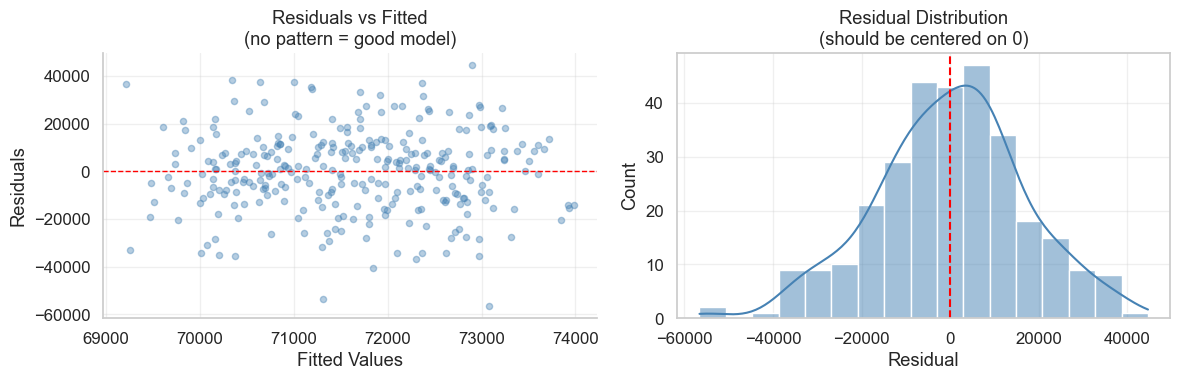

In [17]:
# After training a regression model, always plot residuals
# Residual = actual - predicted
# Good model: residuals randomly scattered around 0 with no pattern
# Bad model: residuals show a curve or funnel (model is missing structure)

from sklearn.linear_model import LinearRegression

X_reg = df[['experience', 'age', 'satisfaction']]
y_reg = df['salary']
reg = LinearRegression().fit(X_reg, y_reg)
y_pred_reg = reg.predict(X_reg)
residuals = y_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(y_pred_reg, residuals, alpha=0.4, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(no pattern = good model)')
axes[0].spines[['top', 'right']].set_visible(False)

# Distribution of residuals (should be ~normal)
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution\n(should be centered on 0)')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

### 2.7 FacetGrid — Same Plot, Multiple Subgroups Automatically

## FacetGrid

FacetGrid creates a **grid of subplots**, one per category. Same plot, split across groups — easy to compare distributions or relationships across categories without writing loop code.

```python
g = sns.FacetGrid(df, col='department', row='gender', hue='target')
g.map(sns.scatterplot, 'age', 'salary')
g.add_legend()
```

- `col=` → splits into columns by category
- `row=` → splits into rows by category
- `hue=` → colors within each subplot by category
- `.map()` → applies any plot function to each subplot

### Example — one column per department

```python
g = sns.FacetGrid(df, col='department', col_wrap=3)
g.map(sns.histplot, 'salary')
```

`col_wrap=3` wraps to a new row after 3 columns — prevents one long horizontal strip.

### When to Use It

- Comparing the same relationship across multiple subgroups
- Checking if a pattern holds consistently across categories
- Replacing a loop that manually creates subplots

> FacetGrid is more flexible than `hue=` alone. `hue` overlaps everything on one plot, FacetGrid gives each group its own panel.

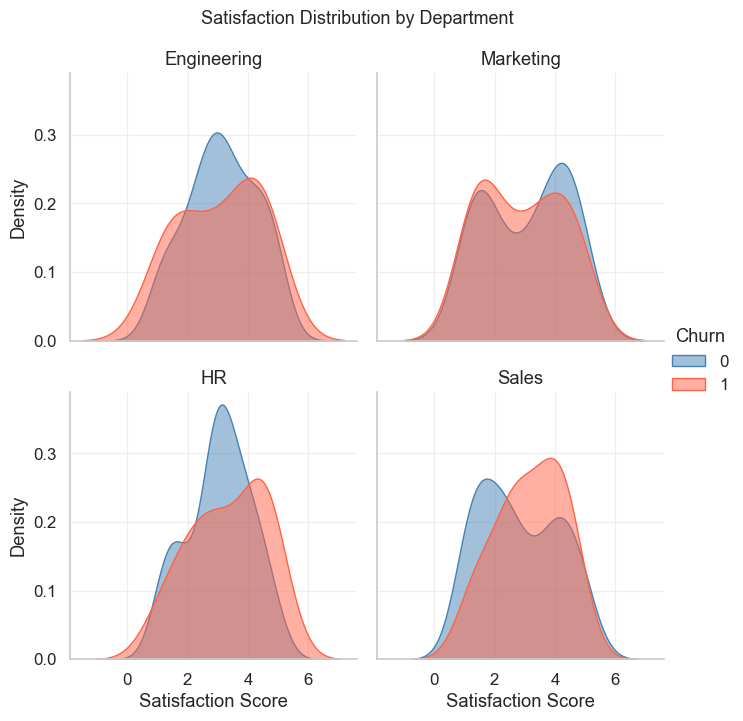

In [18]:
# FacetGrid repeats the same plot for each value of a categorical variable
# Avoids writing a loop to make subplots

g = sns.FacetGrid(df, col='department', hue='churn',
                  palette={0: 'steelblue', 1: 'tomato'},
                  col_wrap=2, height=3.5)
g.map(sns.kdeplot, 'satisfaction', fill=True, alpha=0.5)
g.add_legend(title='Churn')
g.set_axis_labels('Satisfaction Score', 'Density')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Satisfaction Distribution by Department', y=1.03, fontsize=13)
plt.show()

---
## PART 3: Matplotlib + Seaborn Together

They mix freely. Use Seaborn for the chart, then use `ax` to add Matplotlib annotations.

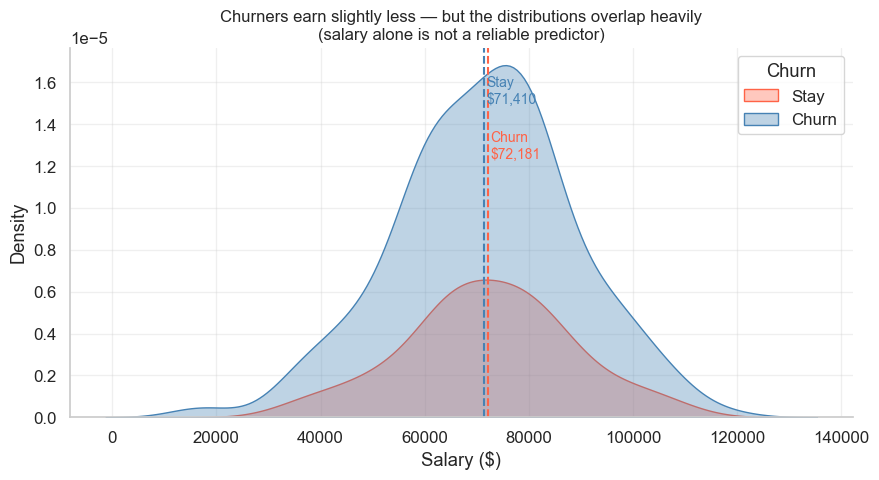

In [19]:
# Seaborn draws the base chart, Matplotlib adds the annotations
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(
    data=df, x='salary', hue='churn',
    palette={0: 'steelblue', 1: 'tomato'},
    fill=True, alpha=0.35, ax=ax
)

# Add mean lines with Matplotlib
mean_stay  = df[df['churn'] == 0]['salary'].mean()
mean_churn = df[df['churn'] == 1]['salary'].mean()

ax.axvline(mean_stay,  color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(mean_churn, color='tomato',    linestyle='--', linewidth=1.5)

ax.text(mean_stay  + 500, ax.get_ylim()[1] * 0.85, f'Stay\n${mean_stay:,.0f}',
        color='steelblue', fontsize=10)
ax.text(mean_churn + 500, ax.get_ylim()[1] * 0.70, f'Churn\n${mean_churn:,.0f}',
        color='tomato', fontsize=10)

ax.set_title('Churners earn slightly less — but the distributions overlap heavily\n(salary alone is not a reliable predictor)', fontsize=12)
ax.set_xlabel('Salary ($)')
ax.legend(title='Churn', labels=['Stay', 'Churn'])
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Quick Reference

### Matplotlib cheat sheet
```python
fig, ax = plt.subplots(figsize=(w, h))        # always start here
fig, axes = plt.subplots(r, c, figsize=(w,h)) # grid of subplots

ax.plot(x, y)              # line
ax.scatter(x, y)           # scatter
ax.bar(x, height)          # vertical bar
ax.barh(y, width)          # horizontal bar
ax.hist(x, bins=30)        # histogram
ax.axhline(y=val)          # horizontal reference line
ax.axvline(x=val)          # vertical reference line
ax.fill_between(x, y1, y2) # shaded band (for CI)

ax.set_title('...')        # chart title
ax.set_xlabel('...')       # axis labels
ax.set_ylabel('...')
ax.legend()
ax.annotate('text', xy=(x,y), xytext=(tx,ty), arrowprops=dict(arrowstyle='->'))
ax.spines[['top','right']].set_visible(False)  # remove borders

plt.tight_layout()         # prevent label clipping
plt.show()
fig.savefig('out.png', dpi=150, bbox_inches='tight')
```

### Seaborn cheat sheet
```python
sns.set_theme(style='whitegrid', palette='muted')

# Distribution
sns.histplot(data=df, x='col', hue='target', kde=True)
sns.kdeplot(data=df, x='col', hue='target', fill=True)
sns.boxplot(data=df, x='cat', y='num', hue='target')
sns.violinplot(data=df, x='cat', y='num', hue='target', split=True)

# Relationships
sns.scatterplot(data=df, x='col1', y='col2', hue='target')
sns.regplot(data=df, x='col1', y='col2')      # scatter + regression line
sns.pairplot(df, hue='target', diag_kind='kde')

# Categorical
sns.barplot(data=df, x='cat', y='num', hue='target')  # mean + CI
sns.countplot(data=df, x='cat', hue='target')

# Matrix
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)

# All seaborn plots accept ax= to embed in a matplotlib figure
sns.histplot(df['col'], ax=axes[0])
```

### When to use what
| Task | Function |
|---|---|
| Training/val loss curves | `ax.plot` (Matplotlib) |
| ROC curve | `ax.plot` + sklearn's `roc_curve` |
| Learning curve | `ax.plot` + `fill_between` |
| Feature importance | `ax.barh` (Matplotlib, sorted) |
| Confusion matrix | `sns.heatmap` |
| Correlation matrix | `sns.heatmap` with `mask=np.triu(...)` |
| Distribution check | `sns.histplot` or `sns.kdeplot` |
| Outlier check | `sns.boxplot` |
| Multivariate EDA | `sns.pairplot` |
| Group comparison | `sns.barplot` or `sns.boxplot` |
| Regression residuals | `ax.scatter(y_pred, residuals)` |